# Support Vector Machines (SVM)

---

## O que é um SVM?

Um **Support Vector Machine** encontra o **hiperplano ótimo** que separa as classes com a **máxima margem** possível.

| Conceito | Definição |
|---|---|
| **Hiperplano de decisão** | Em 2D é uma reta; em nD, um subespaço (n−1)-dimensional. Equação: `w·x + b = 0` |
| **Vetores de suporte** | Os pontos mais próximos ao hiperplano de cada classe. São os únicos que definem o modelo |
| **Margem** | Distância entre os dois hiperplanos de margem (`w·x+b = ±1`). Vale `2 / ‖w‖` |
| **Kernel trick** | Mapeia implicitamente para espaço de maior dimensão sem calcular a transformação explicitamente |

![](https://raw.githubusercontent.com/hsandmann/biblio/refs/heads/main/ml/Classification-of-data-by-support-vector-machine-SVM.webp)

Classification of data by support vector machine (SVM). source: [doi: 10.3390/ma9070531](https://doi.org/10.3390/ma9070531)

### Formulação (hard margin)

$$\min_{w,b} \frac{1}{2} \|w\|^2$$

sujeito a:

$$y_i (w \cdot x_i + b) \geq 1, \quad \forall i$$

onde $y_i \in \{-1, +1\}$ é o rótulo da classe.

## Hard Margin vs. Soft Margin

### Hard Margin

Exige separação **perfeita** — nenhum ponto pode estar dentro ou além da margem.

$$\min_{w,b} \frac{1}{2} \|w\|^2 \quad \text{s.a.} \quad y_i(w \cdot x_i + b) \geq 1$$

**Problema:** sensível a outliers. Um único ponto mal posicionado pode tornar o problema inviável.

### Soft Margin

Introduz **variáveis de folga** $\xi_i \geq 0$ que permitem violações controladas pelo parâmetro $C$:

$$\min_{w,b,\xi} \frac{1}{2} \|w\|^2 + C \sum_i \xi_i$$

sujeito a:

$$y_i(w \cdot x_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0$$

| Valor de $\xi_i$ | Significado |
|---|---|
| $\xi_i = 0$ | Ponto correto, fora da margem |
| $0 < \xi_i \leq 1$ | Dentro da faixa de margem, mas lado correto |
| $\xi_i > 1$ | Erro de classificação |

### Efeito do parâmetro C

| C | Margem | Tolerância a erros | Risco |
|---|---|---|---|
| Pequeno (0.01) | Larga | Alta | Underfitting |
| Médio (1.0) | Equilibrada | Média | Ponto de partida |
| Grande (100) | Estreita | Baixa | Overfitting |

> **Dica:** C → ∞ equivale ao hard margin. C → 0 abre a margem ao máximo.

### Visualização: Hard vs. Soft Margin

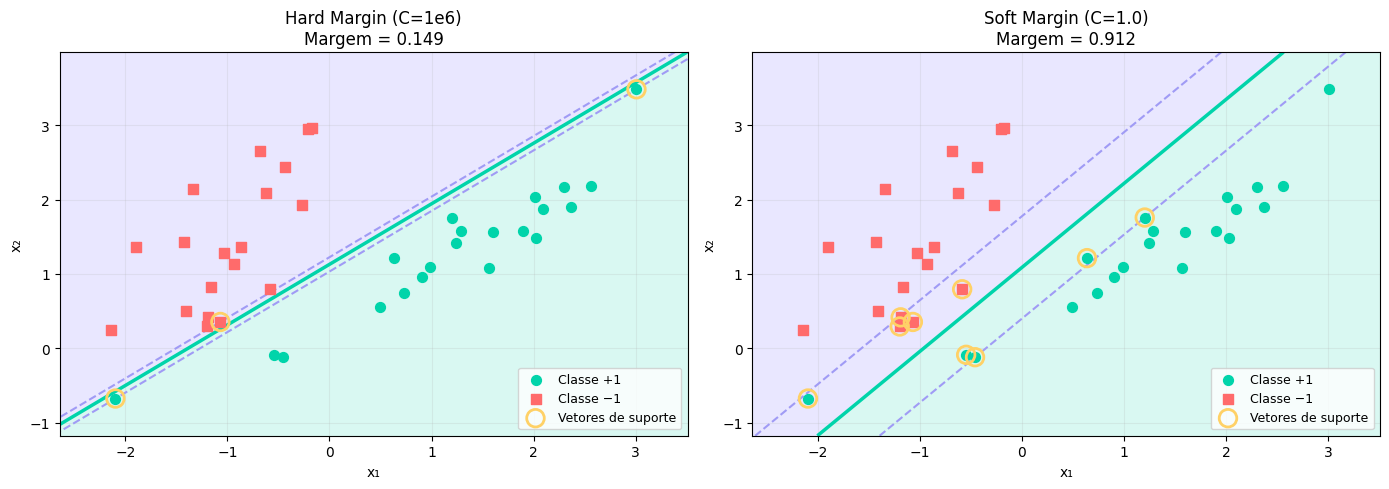

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification

# Dados com algum ruído para demonstrar soft margin
np.random.seed(42)
X, y = make_classification(n_samples=40, n_features=2, n_redundant=0,
                            n_clusters_per_class=1, class_sep=1.2,
                            flip_y=0.05, random_state=42)
y = np.where(y == 0, -1, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, C, title in zip(axes, [1e6, 1.0], ['Hard Margin (C=1e6)', 'Soft Margin (C=1.0)']):
    clf = SVC(kernel='linear', C=C)
    clf.fit(X, y)

    # Grid para fronteira
    xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300),
                         np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 300))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Regiões
    ax.contourf(xx, yy, Z, levels=[-1e9, 0, 1e9],
                colors=['#6c63ff', '#00d4aa'], alpha=0.15)
    # Hiperplano e margens
    ax.contour(xx, yy, Z, levels=[-1, 0, 1],
               colors=['#a09bf5', '#00d4aa', '#a09bf5'],
               linestyles=['--', '-', '--'], linewidths=[1.5, 2.5, 1.5])

    # Pontos
    ax.scatter(X[y==1, 0], X[y==1, 1], c='#00d4aa', s=50, zorder=3, label='Classe +1')
    ax.scatter(X[y==-1, 0], X[y==-1, 1], c='#ff6b6b', s=50, marker='s',
               zorder=3, label='Classe −1')

    # Vetores de suporte
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
               s=160, facecolors='none', edgecolors='#ffd166',
               linewidths=2, zorder=4, label='Vetores de suporte')

    # Anotação da margem
    w = clf.coef_[0]
    margem = 2 / np.linalg.norm(w)
    ax.set_title(f'{title}\nMargem = {margem:.3f}', fontsize=12)
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## Como Calcular a Margem

### Passo a passo

Dado um hiperplano treinado com $w = [w_1, w_2, \ldots, w_n]$ e bias $b$:

**1. Calcular a norma de w:**
$$\|w\| = \sqrt{w_1^2 + w_2^2 + \cdots + w_n^2}$$

**2. Margem total:**
$$\gamma = \frac{2}{\|w\|}$$

**3. Distância de um ponto $x$ ao hiperplano:**
$$d(x) = \frac{|w \cdot x + b|}{\|w\|}$$

**4. Classificar novo ponto:**
$$\hat{y} = \text{sinal}(w \cdot x_{\text{new}} + b)$$

### Exemplo numérico

Para $w = [3, 4]$, $b = -5$:

$$\|w\| = \sqrt{9 + 16} = 5$$

$$\gamma = \frac{2}{5} = 0{,}40 \text{ unidades}$$

Verificando vetor de suporte $x = [0.5, 0.875]$ (está na margem $+1$):

$$w \cdot x + b = 3(0.5) + 4(0.875) - 5 = 1.5 + 3.5 - 5 = 0 \neq 1$$

> Nota: os vetores de suporte satisfazem $y_i(w \cdot x_i + b) = 1$ **após** a normalização interna do otimizador.

### Visualização: geometria da margem (w=[3,4], b=−5)

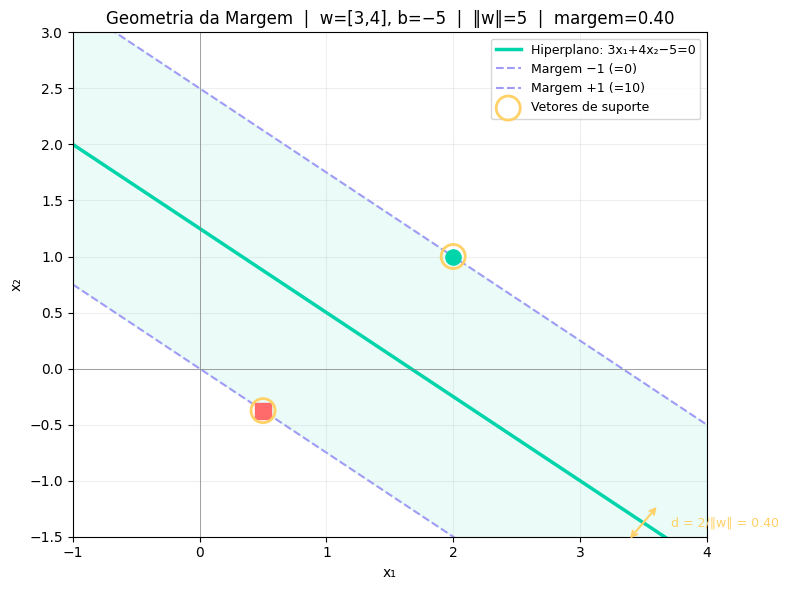

‖w‖  = √(3² + 4²) = √25 = 5.0
Margem total (γ) = 2 / 5.0 = 0.400
Margem por lado  = 1 / 5.0 = 0.200


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

w = np.array([3.0, 4.0])
b = -5.0
norm_w = np.linalg.norm(w)
margem = 2 / norm_w

x1 = np.linspace(-1, 4, 300)

# Hiperplano: 3x1 + 4x2 - 5 = 0  →  x2 = (5 - 3x1) / 4
def linha(x1, rhs=5):
    return (rhs - 3*x1) / 4

ax.plot(x1, linha(x1, 5),  color='#00d4aa', lw=2.5, label='Hiperplano: 3x₁+4x₂−5=0')
ax.plot(x1, linha(x1, 0),  color='#a09bf5', lw=1.5, ls='--', label='Margem −1 (=0)')
ax.plot(x1, linha(x1, 10), color='#a09bf5', lw=1.5, ls='--', label='Margem +1 (=10)')

# Preencher região de margem
ax.fill_between(x1, linha(x1, 0), linha(x1, 10), alpha=0.08, color='#00d4aa')

# Vetores de suporte (exemplos)
sv_pos = np.array([[2.0,  (10-6)/4]])   # na margem +1
sv_neg = np.array([[0.5,  (0-1.5)/4]])  # na margem −1
ax.scatter(*sv_pos.T, s=120, c='#00d4aa', zorder=5)
ax.scatter(*sv_neg.T, s=120, c='#ff6b6b', marker='s', zorder=5)
ax.scatter(*sv_pos.T, s=300, facecolors='none', edgecolors='#ffd166', lw=2, zorder=6)
ax.scatter(*sv_neg.T, s=300, facecolors='none', edgecolors='#ffd166', lw=2, zorder=6,
           label=f'Vetores de suporte')

# Seta mostrando a margem
mx, my = 3.5, linha(3.5, 5)
perp = w / norm_w
p1 = np.array([mx, my]) + perp * (1/norm_w)
p2 = np.array([mx, my]) - perp * (1/norm_w)
ax.annotate('', xy=p1, xytext=p2,
            arrowprops=dict(arrowstyle='<->', color='#ffd166', lw=1.5))
ax.text(p1[0]+0.1, (p1[1]+p2[1])/2, f'd = 2/‖w‖ = {margem:.2f}',
        color='#ffd166', fontsize=9, va='center')

ax.set_xlim(-1, 4); ax.set_ylim(-1.5, 3)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.set_title(f'Geometria da Margem  |  w=[3,4], b=−5  |  ‖w‖={norm_w:.0f}  |  margem={margem:.2f}')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
plt.tight_layout()
plt.show()

print(f"‖w‖  = √(3² + 4²) = √{int(3**2+4**2)} = {norm_w:.1f}")
print(f"Margem total (γ) = 2 / {norm_w:.1f} = {margem:.3f}")
print(f"Margem por lado  = 1 / {norm_w:.1f} = {1/norm_w:.3f}")

## Kernel Trick

Quando dados **não são linearmente separáveis** no espaço original, o kernel mapeia implicitamente para um espaço de maior dimensão $\phi(x)$ onde a separação é possível.

A função kernel computa o **produto interno** nesse espaço **sem calcular $\phi$ explicitamente**:

$$K(x, x') = \phi(x) \cdot \phi(x')$$

### Kernels disponíveis no Scikit-learn

- `Linear`: Alta dimensão, NLP, dados linearmente separáveis.

    $K(x,x') = x \cdot x'$

- `RBF (Radial Basis Function)`: **Padrão**. Fronteiras circulares/não-lineares. Maioria dos casos.

    $K(x,x') = e^{-\gamma \|x-x'\|^2}$

- `Poly`: Interações polinomiais; `degree` controla complexidade.

    $K(x,x') = (\gamma x \cdot x' + r)^d$

- `Sigmoid`: Análogo a rede neural; usar com cautela.

    $K(x,x') = \tanh(\gamma x \cdot x' + r)$

### Hiperparâmetros do kernel RBF

- **γ (gamma):** controla o raio de influência de cada ponto
  - γ pequeno → influência ampla → fronteira suave → risco de underfitting
  - γ grande → influência local → fronteira irregular → risco de overfitting
- **C:** trade-off margem/erros
- Sempre tunar **C e gamma juntos** via `GridSearchCV`

### Visualização: efeito do kernel (dados circulares)

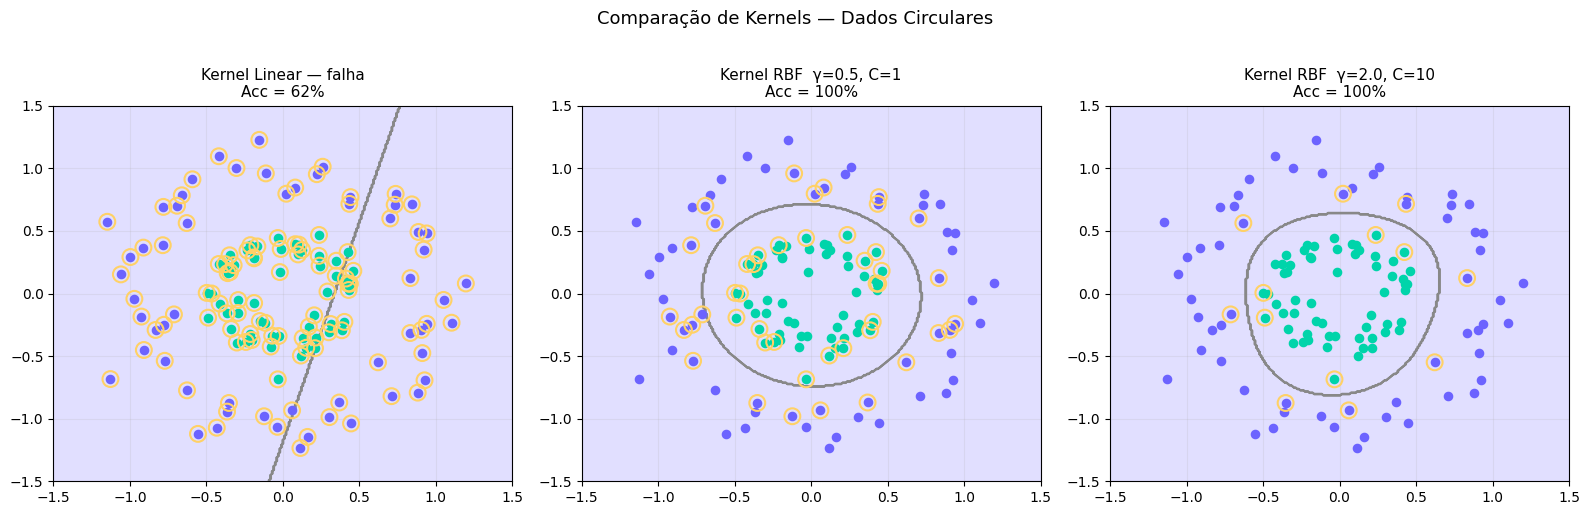

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles

np.random.seed(0)
X, y = make_circles(n_samples=120, noise=0.1, factor=0.4)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

configs = [
    ('linear', 1.0, 'scale', 'Kernel Linear — falha'),
    ('rbf',    1.0, 0.5,     'Kernel RBF  γ=0.5, C=1'),
    ('rbf',   10.0, 2.0,     'Kernel RBF  γ=2.0, C=10'),
]

for ax, (kernel, C, gamma, title) in zip(axes, configs):
    clf = SVC(kernel=kernel, C=C, gamma=gamma)
    clf.fit(X, y)

    xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 300),
                         np.linspace(-1.5, 1.5, 300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.2, colors=['#6c63ff', '#00d4aa'])
    ax.contour(xx, yy, Z, colors=['#888'], linewidths=1)
    ax.scatter(X[y==0, 0], X[y==0, 1], c='#6c63ff', s=35, zorder=3)
    ax.scatter(X[y==1, 0], X[y==1, 1], c='#00d4aa', s=35, zorder=3)
    ax.scatter(clf.support_vectors_[:,0], clf.support_vectors_[:,1],
               s=130, facecolors='none', edgecolors='#ffd166', lw=1.5, zorder=4)

    acc = clf.score(X, y)
    ax.set_title(f'{title}\nAcc = {acc:.0%}', fontsize=11)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.grid(True, alpha=0.2)

plt.suptitle('Comparação de Kernels — Dados Circulares', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Pipeline Completo: Dataset Iris

O Iris tem 150 amostras de 3 espécies com 4 features. Pipeline:

```
Carregar dados → Split estratificado → StandardScaler → SVC(rbf) → GridSearchCV → Avaliação
```

> **Atenção:** sempre aplicar o `StandardScaler` **apenas no treino** e usar `.transform()` no teste. O `Pipeline` do Scikit-learn garante isso automaticamente.

In [ ]:
# ── Instalar / importar dependências
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print("Imports OK")

Imports OK


In [ ]:
# ── 1. Carregar e explorar o dataset
iris = load_iris()
X, y = iris.data, iris.target

print(f"Shape X: {X.shape}")
print(f"Classes: {iris.target_names}")
print(f"Features: {iris.feature_names}")
print(f"Distribuição: {np.bincount(y)}")

Shape X: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Distribuição: [50 50 50]


In [ ]:
# ── 2. Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")

Treino: 120 amostras
Teste:  30 amostras


In [ ]:
# ── 3. Pipeline: StandardScaler + SVC
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc',    SVC(kernel='rbf', probability=True, random_state=42))
])

# ── 4. GridSearchCV para C e gamma
param_grid = {
    'svc__C':     [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 0.01, 0.1, 1]
}
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy',
                    n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)

print(f"Melhores parâmetros: {grid.best_params_}")
print(f"Melhor CV accuracy:  {grid.best_score_:.4f}")

Melhores parâmetros: {'svc__C': 1, 'svc__gamma': 0.1}
Melhor CV accuracy:  0.9750



── Classification Report ──
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



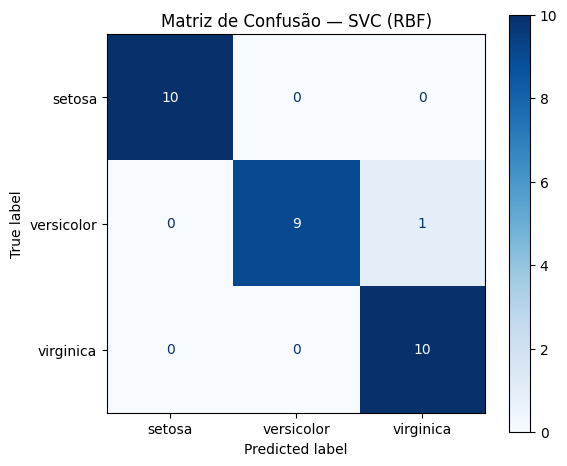

In [ ]:
# ── 5. Avaliação no conjunto de teste
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Matriz de confusão
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=iris.target_names,
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusão — SVC (RBF)')
plt.tight_layout()
plt.show()

In [ ]:
# ── 6. Cross-Validation completo
scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy')
print(f"CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")
print(f"Scores:      {scores.round(4)}")

CV Accuracy: 0.9733 ± 0.0249
Scores:      [0.9667 1.     0.9667 0.9333 1.    ]


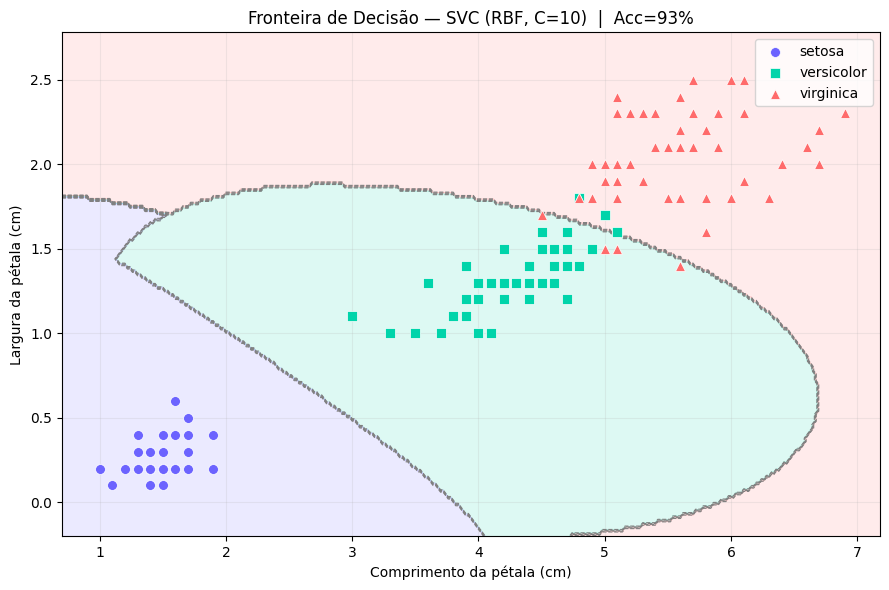

In [ ]:
# ── 7. Fronteira de decisão (2 features: petal length vs petal width)
X2 = X[:, 2:4]   # comprimento e largura da pétala
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)

clf2 = Pipeline([
    ('scaler', StandardScaler()),
    ('svc',    SVC(kernel='rbf', C=10, gamma='scale'))
])
clf2.fit(X2_train, y2_train)

# Grid
h = 0.02
x_min, x_max = X2[:,0].min()-0.3, X2[:,0].max()+0.3
y_min, y_max = X2[:,1].min()-0.3, X2[:,1].max()+0.3
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = clf2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 6))
colors_bg  = ['#6c63ff22', '#00d4aa22', '#ff6b6b22']
colors_fg  = ['#6c63ff',   '#00d4aa',   '#ff6b6b']
markers    = ['o', 's', '^']

from matplotlib.colors import ListedColormap
cmap_bg = ListedColormap(colors_bg)
ax.contourf(xx, yy, Z, cmap=cmap_bg)
ax.contour(xx, yy, Z, colors='gray', linewidths=0.8, linestyles='--')

for i, (name, c, m) in enumerate(zip(iris.target_names, colors_fg, markers)):
    mask = y == i
    ax.scatter(X2[mask, 0], X2[mask, 1], c=c, marker=m, s=50,
               edgecolors='white', linewidths=0.5, label=name, zorder=3)

ax.set_xlabel('Comprimento da pétala (cm)')
ax.set_ylabel('Largura da pétala (cm)')
ax.set_title(f'Fronteira de Decisão — SVC (RBF, C=10)  |  Acc={clf2.score(X2_test, y2_test):.0%}')
ax.legend(); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

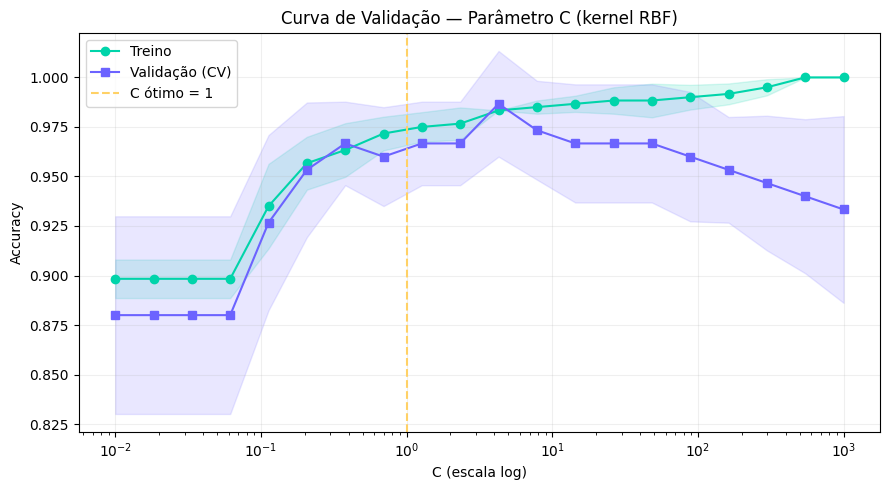

In [ ]:
# ── 8. Curva de validação — efeito de C
from sklearn.model_selection import validation_curve

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C_range = np.logspace(-2, 3, 20)
train_scores, val_scores = validation_curve(
    SVC(kernel='rbf', gamma='scale'), X_scaled, y,
    param_name='C', param_range=C_range, cv=5, scoring='accuracy', n_jobs=-1
)

t_mean, t_std = train_scores.mean(1), train_scores.std(1)
v_mean, v_std = val_scores.mean(1),   val_scores.std(1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(C_range, t_mean, 'o-', color='#00d4aa', label='Treino')
ax.fill_between(C_range, t_mean-t_std, t_mean+t_std, alpha=0.15, color='#00d4aa')
ax.semilogx(C_range, v_mean, 's-', color='#6c63ff', label='Validação (CV)')
ax.fill_between(C_range, v_mean-v_std, v_mean+v_std, alpha=0.15, color='#6c63ff')

ax.axvline(grid.best_params_['svc__C'], color='#ffd166', ls='--', lw=1.5,
           label=f"C ótimo = {grid.best_params_['svc__C']}")
ax.set_xlabel('C (escala log)'); ax.set_ylabel('Accuracy')
ax.set_title('Curva de Validação — Parâmetro C (kernel RBF)')
ax.legend(); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Quando Usar (e Quando Evitar) SVM

### Use SVM quando:
- Dados de **alta dimensão** (features > amostras) — ex: NLP, bioinformática
- Dataset **pequeno a médio** (< 100k amostras)
- Fronteiras de decisão **complexas e não-lineares**
- Precisa de **boa generalização** com poucos dados
- Aplicações: OCR, detecção de anomalias, classificação de imagens

### Evite SVM quando:
- Dataset **muito grande** (> 500k amostras) — custo O(n²) a O(n³) de memória e tempo
- Precisa de **probabilidades calibradas** → prefira Logistic Regression
- Features com **escalas muito diferentes** e normalização é impossível
- **Interpretabilidade** é crítica — SVM é caixa preta
- Dados com **muito ruído** e outliers extremos

### Complexidade computacional

| Operação | Complexidade |
|---|---|
| Treino (aprox.) | O(n² · p) a O(n³) |
| Predição | O(n_sv · p) |
| Memória | O(n²) para a matriz kernel |

onde `n` = amostras, `p` = features, `n_sv` = vetores de suporte.

---


---

- [SkLearn - Support Vector Machines](https://scikit-learn.org/stable/modules/svm.html)

- [Kaggle - SVM Classifier Tutorial](https://www.kaggle.com/code/prashant111/svm-classifier-tutorial)

- [Apoio - SVM](https://tech-espm.github.io/ml/classes/svm)

---
## Exercícios

**Dataset:** Banknote Authentication (UCI)  

**Características do Dataset:**
- 1372 amostras
- 4 features contínuas
- Target binário balanceado (0 = genuína, 1 = falsificada)

**Carregamento do Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import time
import warnings
warnings.filterwarnings('ignore')

# Carregando o dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
columns = ['variance', 'skewness', 'curtosis', 'entropy', 'class']

df = pd.read_csv(url, header=None, names=columns)
X = df.drop('class', axis=1)
y = df['class']

print("Shape:", df.shape)
print("\nDistribuição da classe:\n", y.value_counts())
print("\nDataset balanceado:", y.value_counts(normalize=True))

Shape: (1372, 5)

Distribuição da classe:
 class
0    762
1    610
Name: count, dtype: int64

Dataset balanceado: class
0    0.555394
1    0.444606
Name: proportion, dtype: float64


## Exercício 1: Comparação Completa de Todos os Kernels

**Tarefa:**

1. Aplique `StandardScaler`
1. Divida treino/teste (80/20, `stratify=y`, `random_state=42`)
1. Treine 6 configurações:

    - `kernel='linear'`
    - `kernel='poly', degree=2`
    - `kernel='poly', degree=3`
    - `kernel='rbf', gamma='scale'`
    - `kernel='rbf', gamma=0.1`
    - `kernel='sigmoid'`

1. Para cada um, do tópico anterior, registre:

    - Accuracy, Precision, Recall, F1-score;
    - Tempo de treino
    - Quantidade de `support vectors`

1. Monte uma tabela comparativa (use pandas) e conclua qual kernel é o mais adequado.

## Exercício 2: Grid Search Profundo no Kernel RBF

**Tarefa:**

- Use GridSearchCV (ou RandomizedSearchCV) com:
    - `C`: `[0.1, 1, 10, 50, 100, 500]`
    - `gamma`: `['scale', 'auto', 0.001, 0.01, 0.1, 1, 10]`
    - `kernel=['rbf']`

- Métrica principal: `f1_weighted` ou `accuracy`
- Após o melhor modelo, analise:
    - Como `gamma` alto influencia o overfitting?
    - Como `C` alto afeta a suavidade da fronteira?

- Compare o melhor RBF com o modelo Linear.

## Exercício 3: Visualização das Fronteiras de Decisão (2D)

**Tarefa:**

1. Reduza para 2 dimensões usando `PCA(n_components=2)`
1. Treine novamente os kernels: linear, poly(3), rbf (melhor do exercício 2), sigmoid
1. Crie um subplot 2x2 com as fronteiras de decisão (`contourf`)
1. Plote também os pontos de treino e teste com cores diferentes
1. **Pergunta:** Qual kernel produz a fronteira mais “natural” para este problema de imagens?